# **Trabalho de TCC2 - Aplicando SVR para predizer dimensões físicas de uma antena de microfita**

**Importação e instalação das bibliotecas necessárias**

In [ ]:
# Importing some libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from scipy.constants import c
from pathlib import Path

**Download dos Datasets diretamente do Google Drive**

In [ ]:
# Download all necessary datasets from google drive
!gdown 1B7K2d6nCGhCU59lnIqtFvr0VKXFPrVFg # Real_2,2  nova simulação
!gdown 1uk4Rbq5LiNVOvSJRe4gmgLKvNGhihrAl # Real_3,0  nova simulação
!gdown 1XuQhSzgyFKI_YnZiyG2ngdM3mpin4vtH # Real_4,4  nova simulação
!gdown 1-RJKUOEUTOBFzDWD93IkgisCpSEyNGq3 # Real_6,15 nova simulação
!gdown 1qhGjvbz0P78N2749TOr7ArRN8OblvY9s # Real_10,2 nova simulação

Downloading...
From: https://drive.google.com/uc?id=1B7K2d6nCGhCU59lnIqtFvr0VKXFPrVFg
To: /content/Real_2_2.csv
100% 1.03M/1.03M [00:00<00:00, 47.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1uk4Rbq5LiNVOvSJRe4gmgLKvNGhihrAl
To: /content/Real_3_0.csv
100% 1.03M/1.03M [00:00<00:00, 43.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XuQhSzgyFKI_YnZiyG2ngdM3mpin4vtH
To: /content/Real_4_4.csv
100% 1.03M/1.03M [00:00<00:00, 60.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-RJKUOEUTOBFzDWD93IkgisCpSEyNGq3
To: /content/Real_6_15.csv
100% 1.03M/1.03M [00:00<00:00, 98.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1qhGjvbz0P78N2749TOr7ArRN8OblvY9s
To: /content/Real_10_2.csv
100% 1.02M/1.02M [00:00<00:00, 105MB/s]


---

## **Exploratory Data Analysis**

**Leitura dos arquivos .csv gerados pelo ANSYS**

In [ ]:
# Reading all datasets (1 from each value of epsilon)
arq1 = 'Real_2_2'

df1 = pd.read_csv('/content/drive/MyDrive/TCC2_Gustavo_Joaquim/EDA_TCC2_F_Fixo/Novos_Datasets/Real_2_2.csv')


arq2 = 'Real_3_0'
df2 = pd.read_csv('/content/drive/MyDrive/TCC2_Gustavo_Joaquim/EDA_TCC2_F_Fixo/Novos_Datasets/Real_3_0.csv')


arq3 = 'Real_4_4'
df3 = pd.read_csv('/content/drive/MyDrive/TCC2_Gustavo_Joaquim/EDA_TCC2_F_Fixo/Novos_Datasets/Real_4_4.csv')


arq4 = 'Real_6_15'
df4 = pd.read_csv('/content/drive/MyDrive/TCC2_Gustavo_Joaquim/EDA_TCC2_F_Fixo/Novos_Datasets/Real_6_15.csv')


arq5 = 'Real_10_2'
df5 = pd.read_csv('/content/drive/MyDrive/TCC2_Gustavo_Joaquim/EDA_TCC2_F_Fixo/Novos_Datasets/Real_10_2.csv')

In [ ]:
df1.iloc[19600:19650,:]

,L [mm],Freq [GHz],"re(Z(1,1)) []"
19600,13.864322,3.000000,3.202196
19601,13.864322,3.050251,2.588890
19602,13.864322,3.100503,2.124254
19603,13.864322,3.150754,1.764082
19604,13.864322,3.201005,1.479812
19605,13.864322,3.251256,1.252324
19606,13.864322,3.301508,1.068424
19607,13.864322,3.351759,0.918758
19608,13.864322,3.402010,0.796524
19609,13.864322,3.452261,0.696660


**Renomeando a coluna do Dataset original para possibilitar um acesso mais fácil a métodos do Dataframe**

In [ ]:
# Renaming some columns names
df1.rename(
    columns={"L [mm]": "L", "Freq [GHz]": "Freq", "re(Z(1,1)) []": "re"},
    inplace=True,
)

df2.rename(
    columns={"L [mm]": "L", "Freq [GHz]": "Freq", "re(Z(1,1)) []": "re"},
    inplace=True,
)

df3.rename(
    columns={"L [mm]": "L", "Freq [GHz]": "Freq", "re(Z(1,1)) []": "re"},
    inplace=True,
)

df4.rename(
    columns={"L [mm]": "L", "Freq [GHz]": "Freq", "re(Z(1,1)) []": "re"},
    inplace=True,
)

df5.rename(
    columns={"L [mm]": "L", "Freq [GHz]": "Freq", "re(Z(1,1)) []": "re"},
    inplace=True,
)

**Adicionando uma coluna para h e adicionando uma coluna com L como tipo str para fazer query**

In [ ]:
# Adding a column for 'h' in each dataset
df1['h'] = df1['L'] * 0.0479
df2['h'] = df2['L'] * 0.0479
df3['h'] = df3['L'] * 0.0479
df4['h'] = df4['L'] * 0.0479
df5['h'] = df5['L'] * 0.0479

**Adicionando uma coluna com L como tipo str para fazer query**

In [ ]:
# Adding another 'L' column to the dataset, but as string type, as it will help
# creating subdatasets using pandas query method
df1['L2'] = df1['L'].astype('str')
df2['L2'] = df2['L'].astype('str')
df3['L2'] = df3['L'].astype('str')
df4['L2'] = df4['L'].astype('str')
df5['L2'] = df5['L'].astype('str')

In [ ]:
# Shape (number_of_rows, number_of_columns) of the dataset at its current state
df1.shape, df2.shape, df3.shape, df4.shape, df5.shape

((60200, 5), (60200, 5), (60200, 5), (60200, 5), (60200, 5))

**Criando um novo diretório para trabalhar com os datasets de forma mais simples**

In [ ]:
# Creating a subfolder for storing all subdatasets and easiness to work
pasta = Path("subdatasets")
pasta.mkdir(exist_ok=True) # Cria uma nova pasta com o nome "subdatasets" caso ela já não exista

**Obtendo o caminho do diretório atual**

In [ ]:
# Gets the current workin directory
cur_dir = Path.cwd()
cur_dir

PosixPath('/content')

**Troca o diretório para o diretório criado, armazenando todos os subdatasets criados a partir daqui nessa pasta.**

In [ ]:
# Creates a subdirectory and changes the current working directory to the one
# created
os.chdir(str(cur_dir) + r'/subdatasets')

In [ ]:
Path.cwd()

PosixPath('/content/subdatasets')

**Criação de todos os subdatasets para os diferentes valores de L e de ϵ**

In [ ]:
# Make subdatasets separated by 'L' values using pandas queries to loop over
# an 'L2' column of a dataset, getting all the rows that satisfies the condition
# with its names truncated and with the 1st '.' replaced by '_' using
# str(round(float(x), 2)).replace(".", "_", 1). Same goes for all the other 4
# datasets below

for i in df1['L']:
    x = str(i)
    query_criador_subdatasets1 = df1.query("L2 == @x")
    query_criador_subdatasets1.to_csv('sub' + arq1 + '_' + str(round(float(x), 3)).replace(".", "_", 1) + '.csv', index=False)

In [ ]:
for i in df2['L']:
    x = str(i)
    query_criador_subdatasets2 = df2.query("L2 == @x")
    query_criador_subdatasets2.to_csv('sub' + arq2 + '_' + str(round(float(x), 3)).replace(".", "_", 1) + '.csv', index=False)

In [ ]:
for i in df3['L']:
    x = str(i)
    query_criador_subdatasets3 = df3.query("L2 == @x")
    query_criador_subdatasets3.to_csv('sub' + arq3 + '_' + str(round(float(x), 3)).replace(".", "_", 1) + '.csv', index=False)

In [ ]:
for i in df4['L']:
    x = str(i)
    query_criador_subdatasets4 = df4.query("L2 == @x")
    query_criador_subdatasets4.to_csv('sub' + arq4 + '_' + str(round(float(x), 3)).replace(".", "_", 1) + '.csv', index=False)

In [ ]:
for i in df5['L']:
    x = str(i)
    query_criador_subdatasets5 = df5.query("L2 == @x")
    query_criador_subdatasets5.to_csv('sub' + arq5 + '_' + str(round(float(x), 3)).replace(".", "_", 1) + '.csv', index=False)

Listando os arquivos contidos na pasta

In [ ]:
# Shows all .csv files in the current working directory
arquivos = Path.cwd().glob('**/*.csv')
list(arquivos)

[PosixPath('/content/subdatasets/subReal_10_2_4_833.csv'),
 PosixPath('/content/subdatasets/subReal_10_2_9_17.csv'),
 PosixPath('/content/subdatasets/subReal_3_0_38_485.csv'),
 PosixPath('/content/subdatasets/subReal_6_15_7_271.csv'),
 PosixPath('/content/subdatasets/subReal_3_0_14_887.csv'),
 PosixPath('/content/subdatasets/subReal_10_2_13_636.csv'),
 PosixPath('/content/subdatasets/subReal_2_2_10_714.csv'),
 PosixPath('/content/subdatasets/subReal_4_4_7_527.csv'),
 PosixPath('/content/subdatasets/subReal_2_2_11_709.csv'),
 PosixPath('/content/subdatasets/subReal_6_15_11_052.csv'),
 PosixPath('/content/subdatasets/subReal_4_4_10_932.csv'),
 PosixPath('/content/subdatasets/subReal_3_0_8_766.csv'),
 PosixPath('/content/subdatasets/subReal_4_4_12_778.csv'),
 PosixPath('/content/subdatasets/subReal_2_2_12_704.csv'),
 PosixPath('/content/subdatasets/subReal_3_0_16_945.csv'),
 PosixPath('/content/subdatasets/subReal_10_2_10_342.csv'),
 PosixPath('/content/subdatasets/subReal_2_2_13_533.csv'

**Criando dicionários que irão conter um certo padrão que condiz com o SubDataset.**

In [ ]:
# Making copies of each 'L' Series from each dataset with further purpose of
# looping over it, given that this parammeter is totaly different in each
# dataset. Only one value of each 'L' is necessary and the index has to be
# reseted, and also the series is parsed to a numpy ndarray.

df1_L = df1['L'].copy()
df1_L.drop_duplicates(inplace=True)
df1_L.reset_index(inplace=True, drop=True)
df1_L = df1_L.to_numpy()

In [ ]:
df2_L = df2['L'].copy()
df2_L.drop_duplicates(inplace=True)
df2_L.reset_index(inplace=True, drop=True)
df2_L = df2_L.to_numpy()

In [ ]:
df3_L = df3['L'].copy()
df3_L.drop_duplicates(inplace=True)
df3_L.reset_index(inplace=True, drop=True)
df3_L = df3_L.to_numpy()

In [ ]:
df4_L = df4['L'].copy()
df4_L.drop_duplicates(inplace=True)
df4_L.reset_index(inplace=True, drop=True)
df4_L = df4_L.to_numpy()

In [ ]:
df5_L = df5['L'].copy()
df5_L.drop_duplicates(inplace=True)
df5_L.reset_index(inplace=True, drop=True)
df5_L = df5_L.to_numpy()

In [ ]:
# Shapes of all the different copies created on the previous step
df1_L.shape, df2_L.shape, df3_L.shape, df4_L.shape, df5_L.shape

((301,), (301,), (301,), (301,), (301,))

**Cálculo de todas as frequências de ressonância de acordo com o valor de ϵ**

A equação é:


$\left( \frac{c}{2 * L * \sqrt{ ϵ}} \right) [Hz]$

 $f_{r} = \left( \frac{ 5c \times 10^{-7} } { L\sqrt{\epsilon} } \right) \; \;[GHz]$

 $L = \left( \frac{ 5c \times 10^{-7}}{f_{r}\sqrt{\epsilon}} \right) \; \;[mm]$

Onde $\textit{c}$ é a velocidade da luz e os valores de $L$ devem ser passados em $mm$ e $f_{r}$ em $GHz$


In [ ]:
# Going through the L values for the different datasets to calculate the
# different resonant frequencies. To keep the frequency range the same for all
# datasets, the L values are different for each epsilon value

from math import sqrt
import numpy as np
from scipy.constants import c


df1_L_min = min(df1['L'])
df1_L_max = max(df1['L'])

df2_L_min = min(df2['L'])
df2_L_max = max(df2['L'])

df3_L_min = min(df3['L'])
df3_L_max = max(df3['L'])

df4_L_min = min(df4['L'])
df4_L_max = max(df4['L'])

df5_L_min = min(df5['L'])
df5_L_max = max(df5['L'])




# Função que gera as frequências de ressonância calculadas
def gerar_frequencias(lista_freq:list, eps):
    fr_0_GHz = [(5*c*(10**-7))/(elem * np.sqrt(eps)) for elem in lista_freq]
    return fr_0_GHz


# Chamando a função gerar_frequencias para mapear as frequências de ressonância
# de acordo com o epsilon desejado
lista_freq_epsilon_2_20 = gerar_frequencias(df1_L, eps=2.2)
lista_freq_epsilon_3_00 = gerar_frequencias(df2_L, eps=3)
lista_freq_epsilon_4_40 = gerar_frequencias(df3_L, eps=4.4)
lista_freq_epsilon_6_15 = gerar_frequencias(df4_L, eps=6.15)
lista_freq_epsilon_10_2 = gerar_frequencias(df5_L, eps=10.2)

# Print estético para separação de linhas
print('\-/-\-/'*100)


# Print das listas contendo todos os valores de L e todas as frequências de
# ressonância calculadas para os diferentes valores de L e de epsilon_r
print('Cálculo de valores da frequência de ressonância para todos os valores de epsilon:')
print('\-/-\-/'*100)
print("\n")
print(f"Valores de L[mm] para epsilon = 2.2: {df1_L}")
print("\n")
print('\-/-\-/'*100)
print(f"Valores de L[mm] para epsilon = 3.0: {df2_L}")
print("\n")
print('\-/-\-/'*100)
print(f"Valores de L[mm] para epsilon = 4.4: {df3_L}")
print("\n")
print('\-/-\-/'*100)
print(f"Valores de L[mm] para epsilon = 6.15: {df4_L}")
print("\n")
print('\-/-\-/'*100)
print(f"Valores de L[mm] para epsilon = 10.2: {df5_L}")
print("\n")
print('\-/-\-/'*100)
print(f"Frequências de ressonância para epsilon =  02.20 [GHz]:   {lista_freq_epsilon_2_20}")
print(f"Frequências de ressonância para epsilon =  03.00 [GHz]:   {lista_freq_epsilon_3_00}")
print(f"Frequências de ressonância para epsilon =  04.40 [GHz]:   {lista_freq_epsilon_4_40}")
print(f"Frequências de ressonância para epsilon =  06.15 [GHz]:   {lista_freq_epsilon_6_15}")
print(f"Frequências de ressonância para epsilon =  10.20 [GHz]:   {lista_freq_epsilon_10_2}")

# Print estético para separação de linhas
print("\n")
print('\-/-\-/'*100)


\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/
Cálculo de valores da frequência de ressonância para todos os valores de epsilon:
\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/\-/-\-/

In [ ]:
len(lista_freq_epsilon_10_2)

301

In [ ]:
# Grouping the datasets in a dictionary by the epsilon value
dict_2_2 = {}
dict_3_0 = {}
dict_4_4 = {}
dict_6_15 = {}
dict_10_2 = {}


for i in df1_L:
    dict_2_2.update({'Real_2_2_' + str(round(i, 3)).replace(".", "_", 1): pd.read_csv('sub' + 'Real_2_2_' + str(round(i, 3)).replace(".", "_", 1) + '.csv')})

for i in df2_L:
    dict_3_0.update({'Real_3_0_' + str(round(i, 3)).replace(".", "_", 1): pd.read_csv('sub' + 'Real_3_0_' + str(round(i, 3)).replace(".", "_", 1) + '.csv')})

for i in df3_L:
    dict_4_4.update({'Real_4_4_' + str(round(i, 3)).replace(".", "_", 1): pd.read_csv('sub' + 'Real_4_4_' + str(round(i, 3)).replace(".", "_", 1) + '.csv')})

for i in df4_L:
    dict_6_15.update({'Real_6_15_' + str(round(i, 3)).replace(".", "_", 1): pd.read_csv('sub' + 'Real_6_15_' + str(round(i, 3)).replace(".", "_", 1) + '.csv')})

for i in df5_L:
    dict_10_2.update({'Real_10_2_' + str(round(i, 3)).replace(".", "_", 1): pd.read_csv('sub' + 'Real_10_2_' + str(round(i, 3)).replace(".", "_", 1) + '.csv')})


**Mostrando um dos SubDatasets atualizados**

In [ ]:
dict_3_0.keys()

dict_keys(['Real_3_0_5_0', 'Real_3_0_5_859', 'Real_3_0_6_717', 'Real_3_0_7_5', 'Real_3_0_7_553', 'Real_3_0_7_576', 'Real_3_0_7_606', 'Real_3_0_7_658', 'Real_3_0_7_711', 'Real_3_0_7_764', 'Real_3_0_7_817', 'Real_3_0_7_869', 'Real_3_0_7_922', 'Real_3_0_7_975', 'Real_3_0_8_028', 'Real_3_0_8_08', 'Real_3_0_8_133', 'Real_3_0_8_186', 'Real_3_0_8_239', 'Real_3_0_8_291', 'Real_3_0_8_344', 'Real_3_0_8_397', 'Real_3_0_8_434', 'Real_3_0_8_45', 'Real_3_0_8_503', 'Real_3_0_8_555', 'Real_3_0_8_608', 'Real_3_0_8_661', 'Real_3_0_8_714', 'Real_3_0_8_766', 'Real_3_0_8_819', 'Real_3_0_8_872', 'Real_3_0_8_925', 'Real_3_0_8_977', 'Real_3_0_9_03', 'Real_3_0_9_083', 'Real_3_0_9_136', 'Real_3_0_9_188', 'Real_3_0_9_241', 'Real_3_0_9_293', 'Real_3_0_9_294', 'Real_3_0_9_347', 'Real_3_0_9_399', 'Real_3_0_9_452', 'Real_3_0_9_505', 'Real_3_0_9_558', 'Real_3_0_9_611', 'Real_3_0_9_663', 'Real_3_0_9_716', 'Real_3_0_9_769', 'Real_3_0_9_822', 'Real_3_0_9_874', 'Real_3_0_9_927', 'Real_3_0_9_98', 'Real_3_0_10_033', 'Real_

In [ ]:
# Information about 'dict_2_2['Real_2_2_5_0']'
dict_2_2['Real_2_2_10_051'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   L       200 non-null    float64
 1   Freq    200 non-null    float64
 2   re      200 non-null    float64
 3   h       200 non-null    float64
 4   L2      200 non-null    float64
dtypes: float64(5)
memory usage: 7.9 KB


In [ ]:
# Showing the data
len(dict_10_2.keys())

301

In [ ]:
# Showing the last 50 values of this specific dataset for epsilon = 3 and
# L = 78.84 mm
dict_3_0['Real_3_0_78_838'].tail(50)

,L,Freq,re,h,L2
150,78.838384,8.513065,101.046888,3.776359,78.838384
151,78.838384,8.563819,111.758820,3.776359,78.838384
152,78.838384,8.614573,81.381586,3.776359,78.838384
153,78.838384,8.665327,54.961094,3.776359,78.838384
154,78.838384,8.716080,41.114125,3.776359,78.838384
155,78.838384,8.766834,35.269867,3.776359,78.838384
156,78.838384,8.817588,35.870913,3.776359,78.838384
157,78.838384,8.868342,44.311950,3.776359,78.838384
158,78.838384,8.919095,53.881868,3.776359,78.838384
159,78.838384,8.969849,47.292824,3.776359,78.838384


**Utilizando a janela móvel para descobrir os picos e vales dos dados discretos dos Datasets**

In [ ]:
# Using a rolling window to find wich points are bigger than the previous one
# evaluating the 'max_re' column. A new column 'pico_re' is also initialized
# with False
window_size = 1

for i in df1_L:
    dict_2_2['Real_2_2_' + str(round(i, 3)).replace(".", "_", 1)]['max_re'] = dict_2_2['Real_2_2_' + str(round(i, 3)).replace(".", "_", 1)]['re'].rolling(window_size, min_periods=0).max()
    dict_2_2['Real_2_2_' + str(round(i, 3)).replace(".", "_", 1)]['Maior_que_anterior'] = (dict_2_2['Real_2_2_' + str(round(i, 3)).replace(".", "_", 1)]['re'] == dict_2_2['Real_2_2_' + str(round(i, 3)).replace(".", "_", 1)]['max_re']) & (dict_2_2['Real_2_2_' + str(round(i, 3)).replace(".", "_", 1)]['re'] > dict_2_2['Real_2_2_' + str(round(i, 3)).replace(".", "_", 1)]['re'].shift())
    dict_2_2['Real_2_2_' + str(round(i, 3)).replace(".", "_", 1)]['Pico_re'] = False


for i in df2_L:
    dict_3_0['Real_3_0_' + str(round(i, 3)).replace(".", "_", 1)]['max_re'] = dict_3_0['Real_3_0_' +  str(round(i, 3)).replace(".", "_", 1)]['re'].rolling(window_size, min_periods=0).max()
    dict_3_0['Real_3_0_' + str(round(i, 3)).replace(".", "_", 1)]['Maior_que_anterior'] = (dict_3_0['Real_3_0_' +  str(round(i, 3)).replace(".", "_", 1)]['re'] == dict_3_0['Real_3_0_' +  str(round(i, 3)).replace(".", "_", 1)]['max_re']) & (dict_3_0['Real_3_0_' +  str(round(i, 3)).replace(".", "_", 1)]['re'] > dict_3_0['Real_3_0_' +  str(round(i, 3)).replace(".", "_", 1)]['re'].shift())
    dict_3_0['Real_3_0_' + str(round(i, 3)).replace(".", "_", 1)]['Pico_re'] = False



for i in df3_L:
    dict_4_4['Real_4_4_' + str(round(i, 3)).replace(".", "_", 1)]['max_re'] =  dict_4_4['Real_4_4_' +  str(round(i, 3)).replace(".", "_", 1)]['re'].rolling(window_size, min_periods=0).max()
    dict_4_4['Real_4_4_' + str(round(i, 3)).replace(".", "_", 1)]['Maior_que_anterior'] = (dict_4_4['Real_4_4_' +  str(round(i, 3)).replace(".", "_", 1)]['re'] ==  dict_4_4['Real_4_4_' +  str(round(i, 3)).replace(".", "_", 1)]['max_re']) & ( dict_4_4['Real_4_4_' +  str(round(i, 3)).replace(".", "_", 1)]['re'] >  dict_4_4['Real_4_4_' +  str(round(i, 3)).replace(".", "_", 1)]['re'].shift())
    dict_4_4['Real_4_4_' + str(round(i, 3)).replace(".", "_", 1)]['Pico_re'] = False



for i in df4_L:
    dict_6_15['Real_6_15_' + str(round(i, 3)).replace(".", "_", 1)]['max_re'] = dict_6_15['Real_6_15_' +  str(round(i, 3)).replace(".", "_", 1)]['re'].rolling(window_size, min_periods=0).max()
    dict_6_15['Real_6_15_' + str(round(i, 3)).replace(".", "_", 1)]['Maior_que_anterior'] = (dict_6_15['Real_6_15_' +  str(round(i, 3)).replace(".", "_", 1)]['re'] == dict_6_15['Real_6_15_' +  str(round(i, 3)).replace(".", "_", 1)]['max_re']) & (dict_6_15['Real_6_15_' +  str(round(i, 3)).replace(".", "_", 1)]['re'] > dict_6_15['Real_6_15_' +  str(round(i, 3)).replace(".", "_", 1)]['re'].shift())
    dict_6_15['Real_6_15_' + str(round(i, 3)).replace(".", "_", 1)]['Pico_re'] = False



for i in df5_L:
    dict_10_2['Real_10_2_' + str(round(i, 3)).replace(".", "_", 1)]['max_re'] = dict_10_2['Real_10_2_' +  str(round(i, 3)).replace(".", "_", 1)]['re'].rolling(window_size, min_periods=0).max()
    dict_10_2['Real_10_2_' + str(round(i, 3)).replace(".", "_", 1)]['Maior_que_anterior'] = (dict_10_2['Real_10_2_' +  str(round(i, 3)).replace(".", "_", 1)]['re'] == dict_10_2['Real_10_2_' +  str(round(i, 3)).replace(".", "_", 1)]['max_re']) & (dict_10_2['Real_10_2_' +  str(round(i, 3)).replace(".", "_", 1)]['re'] > dict_10_2['Real_10_2_' +  str(round(i, 3)).replace(".", "_", 1)]['re'].shift())
    dict_10_2['Real_10_2_' + str(round(i, 3)).replace(".", "_", 1)]['Pico_re'] = False


**Mostrando o um dos Datasets dentro do dicionário atualizado.**

In [ ]:
# Updated dataset
dict_2_2['Real_2_2_5_0'].tail(50)

,L,Freq,re,h,L2,max_re,Maior_que_anterior,Pico_re
150,5.0,7.783920,1.697226,0.2395,5.0,1.697226,True,False
151,5.0,7.829146,1.749011,0.2395,5.0,1.749011,True,False
152,5.0,7.874372,1.803491,0.2395,5.0,1.803491,True,False
153,5.0,7.919598,1.860837,0.2395,5.0,1.860837,True,False
154,5.0,7.964824,1.921236,0.2395,5.0,1.921236,True,False
155,5.0,8.010050,1.984891,0.2395,5.0,1.984891,True,False
156,5.0,8.055276,2.052021,0.2395,5.0,2.052021,True,False
157,5.0,8.100503,2.122869,0.2395,5.0,2.122869,True,False
158,5.0,8.145729,2.197696,0.2395,5.0,2.197696,True,False
159,5.0,8.190955,2.276791,0.2395,5.0,2.276791,True,False


**Percorrendo o dicionário que contém os Datasets e aplicando a operação lógica a seguir na coluna 'Maior_que_anterior':**

**Caso um ponto na coluna 'Maior_que_anterior' seja True e o próximo ponto seja False, isso indica que temos um máximo local no Dataset, e é justamente esse ponto que devemos pegar**

In [ ]:
# This is the main logic of the process:
# We are intrested only in local maxima, as they gives the resonant frequency
# for all modes of operation of the antenna. When a point in the column
# 'maior_que_anterior' is True and the very next point is False, that
# indicates that this point is a summit, therefore a value True for that row
# should be placed in the column 'pico_re'

for i in range(0,199):
    for j in df1_L:
        dict_2_2['Real_2_2_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i, 7] =  dict_2_2['Real_2_2_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i,6] and ~ dict_2_2['Real_2_2_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i+1,6]


for i in range(0,199):
    for j in df2_L:
        dict_3_0['Real_3_0_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i, 7] =  dict_3_0['Real_3_0_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i,6] and ~ dict_3_0['Real_3_0_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i+1,6]


for i in range(0,199):
    for j in df3_L:
        dict_4_4['Real_4_4_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i, 7] =  dict_4_4['Real_4_4_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i,6] and ~ dict_4_4['Real_4_4_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i+1,6]


for i in range(0,199):
    for j in df4_L:
        dict_6_15['Real_6_15_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i, 7] = dict_6_15['Real_6_15_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i,6] and ~ dict_6_15['Real_6_15_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i+1,6]


for i in range(0,199):
    for j in df5_L:
        dict_10_2['Real_10_2_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i, 7] = dict_10_2['Real_10_2_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i,6] and ~ dict_10_2['Real_10_2_' + str(round(j, 3)).replace(".", "_", 1)].iloc[i+1,6]

**Mostrando o Dataset agora com a coluna 'Pico_re' atualizada para contar se um valor na coluna 'Maior_que_anterior' passou de um valor True para False ou não.**

In [ ]:
# Show nome data updated
dict_3_0['Real_3_0_5_0'].iloc[100:150,:]

,L,Freq,re,h,L2,max_re,Maior_que_anterior,Pico_re
100,5.0,5.522613,0.344159,0.2395,5.0,0.344159,True,False
101,5.0,5.567839,0.349549,0.2395,5.0,0.349549,True,False
102,5.0,5.613065,0.355089,0.2395,5.0,0.355089,True,False
103,5.0,5.658291,0.360782,0.2395,5.0,0.360782,True,False
104,5.0,5.703518,0.366635,0.2395,5.0,0.366635,True,False
105,5.0,5.748744,0.372652,0.2395,5.0,0.372652,True,False
106,5.0,5.793970,0.378840,0.2395,5.0,0.378840,True,False
107,5.0,5.839196,0.385205,0.2395,5.0,0.385205,True,False
108,5.0,5.884422,0.391752,0.2395,5.0,0.391752,True,False
109,5.0,5.929648,0.398488,0.2395,5.0,0.398488,True,False


**Itera sobre o dicionário que contém todos os Datasets e adiciona em todos eles uma coluna que contém a diferença absoluta entre os valores de frequência de ressonância calculadas e frequência de ressonância simulada pelo Ansys.**

In [ ]:
# At this point, all resonant frequencies were taken, but we still only need
# the ones for the fundamental mode. This is where the calculade values come in
# as we calculate the absolute difference between the calculated value and the
# simulated value, taking the minimum as the point of fundamental mode.

indice1, indice2, indice3, indice4, indice5  = 0, 0, 0, 0, 0

for j in df1_L:
    dict_2_2['Real_2_2_' + str(round(j, 3)).replace(".", "_", 1)]['Diferenca_fr_calculado_simulado'] =  abs(dict_2_2['Real_2_2_' + str(round(j, 3)).replace(".", "_", 1)]['Freq'] - lista_freq_epsilon_2_20[indice1])
    indice1+=1



for j in df2_L:
    dict_3_0['Real_3_0_' + str(round(j, 3)).replace(".", "_", 1)]['Diferenca_fr_calculado_simulado'] =  abs(dict_3_0['Real_3_0_' + str(round(j, 3)).replace(".", "_", 1)]['Freq'] - lista_freq_epsilon_3_00[indice2])
    indice2+=1




for j in df3_L:
    dict_4_4['Real_4_4_' + str(round(j, 3)).replace(".", "_", 1)]['Diferenca_fr_calculado_simulado'] =  abs(dict_4_4['Real_4_4_' + str(round(j, 3)).replace(".", "_", 1)]['Freq'] - lista_freq_epsilon_4_40[indice3])
    indice3+=1




for j in df4_L:
    dict_6_15['Real_6_15_' + str(round(j, 3)).replace(".", "_", 1)]['Diferenca_fr_calculado_simulado'] = abs(dict_6_15['Real_6_15_' + str(round(j, 3)).replace(".", "_", 1)]['Freq'] - lista_freq_epsilon_6_15[indice4])
    indice4+=1



for j in df5_L:
    dict_10_2['Real_10_2_' + str(round(j, 3)).replace(".", "_", 1)]['Diferenca_fr_calculado_simulado'] = abs(dict_10_2['Real_10_2_' + str(round(j, 3)).replace(".", "_", 1)]['Freq'] - lista_freq_epsilon_10_2[indice5])
    indice5+=1



**Mostra o *Dataset* atualizado com a coluna 'Diferenca_fr_calculado_simulado'**

**Com a nova forma, o código abaixo se refere a query para acessar os dicionários que contem todos os subdatasets e todas as colunas necessárias para avaliar a frequância de ressonância.**

In [ ]:
# For this case, there are possibilities that come filter might be empty,
# therefore, that has to be fixed in some way ahead.
novo_teste_dataframe = dict_3_0['Real_3_0_5_0'].query('Pico_re == True').copy()
novo_teste_dataframe

,L,Freq,re,h,L2,max_re,Maior_que_anterior,Pico_re,Diferenca_fr_calculado_simulado


**Cria um filtro dentro do *SubDataset* que retornará somente a linha onde há True na coluna 'Pico_re' e a coluna 'Diferenca_fr_calculado_simulado' é o valor mínimo, sendo esse ponto aquele que contém a frequência de ressonância desejada**

In [ ]:
novo_teste_dataframe[((novo_teste_dataframe['Diferenca_fr_calculado_simulado'] == \
                       novo_teste_dataframe['Diferenca_fr_calculado_simulado'].min()) & \
                      (novo_teste_dataframe['Pico_re'] == True))]

,L,Freq,re,h,L2,max_re,Maior_que_anterior,Pico_re,Diferenca_fr_calculado_simulado


---

**Criando 5 Datasets finais (1 para cada ϵ), inicialmente contendo 31 linhas todas com valores nulos,falsos ou uma string '0'**

In [ ]:
# Creating 5 empty datasets
dataframe_antenas_final_2_2 = pd.DataFrame({'L':[0],
                                            'Freq':[0],
                                            're':[0],
                                            'h':[0],
                                            'L2':0,
                                            'max_re':[0],
                                            'Maior_que_anterior':[True],
                                            'Pico_re':[True],
                                            'Diferenca_fr_calculado_simulado':[0]},
                                            index=np.arange(len(dict_2_2.keys()))
                                            )


In [ ]:
dataframe_antenas_final_3_0 = pd.DataFrame({'L':[0],
                                            'Freq':[0],
                                            're':[0],
                                            'h':[0],
                                            'L2':0,
                                            'max_re':[0],
                                            'Maior_que_anterior':[True],
                                            'Pico_re':[True],
                                            'Diferenca_fr_calculado_simulado':[0]},
                                            index=np.arange(len(dict_3_0.keys()))
                                            )


In [ ]:
dataframe_antenas_final_4_4 = pd.DataFrame({'L':[0],
                                            'Freq':[0],
                                            're':[0],
                                            'h':[0],
                                            'L2':0,
                                            'max_re':[0],
                                            'Maior_que_anterior':[True],
                                            'Pico_re':[True],
                                            'Diferenca_fr_calculado_simulado':[0]},
                                            index=np.arange(len(dict_4_4.keys()))
                                            )


In [ ]:
dataframe_antenas_final_6_15 = pd.DataFrame({'L':[0],
                                            'Freq':[0],
                                            're':[0],
                                            'h':[0],
                                            'L2':0,
                                            'max_re':[0],
                                            'Maior_que_anterior':[True],
                                            'Pico_re':[True],
                                            'Diferenca_fr_calculado_simulado':[0]},
                                            index=np.arange(len(dict_6_15.keys()))
                                            )

In [ ]:
dataframe_antenas_final_10_2 = pd.DataFrame({'L':[0],
                                            'Freq':[0],
                                            're':[0],
                                            'h':[0],
                                            'L2':0,
                                            'max_re':[0],
                                            'Maior_que_anterior':[True],
                                            'Pico_re':[True],
                                            'Diferenca_fr_calculado_simulado':[0]},
                                            index=np.arange(len(dict_10_2.keys()))
                                            )


**Filtrando os Datasets para obter somente os linhas que contém as frequências de ressonância reais e copiando-as para um novo Dataset final.**

In [ ]:
# Add the filtered data to the newly created dataframes. For this process,
# an {if else} with a continue keyword had to be add, in case the filters
# don't find data to be filtered, otherwise there'd be an error thrown

index1, index2, index3, index4, index5 = 0, 0, 0, 0, 0
for i in df1_L:
    filtro_final = dict_2_2['Real_2_2_' + str(round(i, 3)).replace(".", "_", 1)].query('Pico_re == True').copy()
    filtro_final = filtro_final[((filtro_final['Diferenca_fr_calculado_simulado'] == \
                                  filtro_final['Diferenca_fr_calculado_simulado'].min()) & \
                                 (filtro_final['Pico_re'] == True))].copy()
    filtro_final.reset_index(inplace=True, drop=True)
    if filtro_final.shape[0] == 0:
        continue
    else:
        dataframe_antenas_final_2_2.iloc[index1] = filtro_final.copy()
        index1+=1




for i in df2_L:
    filtro_final1 = dict_3_0['Real_3_0_' + str(round(i, 3)).replace(".", "_", 1)].query('Pico_re == True').copy()
    filtro_final1 = filtro_final1[((filtro_final1['Diferenca_fr_calculado_simulado'] == \
                                  filtro_final1['Diferenca_fr_calculado_simulado'].min()) & \
                                 (filtro_final1['Pico_re'] == True))].copy()
    filtro_final1.reset_index(inplace=True, drop=True)
    if filtro_final1.shape[0] == 0:
        continue
    else:
        dataframe_antenas_final_3_0.iloc[index2] = filtro_final1.copy()
        index2+=1





for i in df3_L:
    filtro_final2 = dict_4_4['Real_4_4_' + str(round(i, 3)).replace(".", "_", 1)].query('Pico_re == True').copy()
    filtro_final2 = filtro_final2[((filtro_final2['Diferenca_fr_calculado_simulado'] == \
                                  filtro_final2['Diferenca_fr_calculado_simulado'].min()) & \
                                 (filtro_final2['Pico_re'] == True))].copy()
    filtro_final2.reset_index(inplace=True, drop=True)
    if filtro_final2.shape[0] == 0:
        continue
    else:
        dataframe_antenas_final_4_4.iloc[index3] = filtro_final2.copy()
        index3+=1




for i in df4_L:
    filtro_final3 = dict_6_15['Real_6_15_' + str(round(i, 3)).replace(".", "_", 1)].query('Pico_re == True').copy()
    filtro_final3 = filtro_final3[((filtro_final3['Diferenca_fr_calculado_simulado'] == \
                                  filtro_final3['Diferenca_fr_calculado_simulado'].min()) & \
                                 (filtro_final3['Pico_re'] == True))].copy()
    filtro_final3.reset_index(inplace=True, drop=True)
    if filtro_final3.shape[0] == 0:
        continue
    else:
        dataframe_antenas_final_6_15.iloc[index4] = filtro_final3.copy()
        index4+=1




for i in df5_L:
    filtro_final4 = dict_10_2['Real_10_2_' + str(round(i, 3)).replace(".", "_", 1)].query('Pico_re == True').copy()
    filtro_final4 = filtro_final4[((filtro_final4['Diferenca_fr_calculado_simulado'] == \
                                  filtro_final4['Diferenca_fr_calculado_simulado'].min()) & \
                                 (filtro_final4['Pico_re'] == True))].copy()
    filtro_final4.reset_index(inplace=True, drop=True)
    if filtro_final4.shape[0] == 0:
        continue
    else:
        dataframe_antenas_final_10_2.iloc[index5] = filtro_final4.copy()
        index5+=1

Extraíndo os valores mínimos de 'L'

In [ ]:
# Showing the minimum frequencies of each dataset
minimo_freq_2_2 = dataframe_antenas_final_2_2['Freq'].loc[dataframe_antenas_final_2_2['Freq'] != 0].min()
minimo_freq_3_0 = dataframe_antenas_final_3_0['Freq'].loc[dataframe_antenas_final_3_0['Freq'] != 0].min()
minimo_freq_4_4 = dataframe_antenas_final_4_4['Freq'].loc[dataframe_antenas_final_4_4['Freq'] != 0].min()
minimo_freq_6_15 = dataframe_antenas_final_6_15['Freq'].loc[dataframe_antenas_final_6_15['Freq'] != 0].min()
minimo_freq_10_2 = dataframe_antenas_final_10_2['Freq'].loc[dataframe_antenas_final_10_2['Freq'] != 0].min()

In [ ]:
minimo_freq_2_2, minimo_freq_3_0, minimo_freq_4_4, minimo_freq_6_15, minimo_freq_10_2

(0.960804020100502,
 0.950753768844221,
 0.950753768844221,
 0.950753768844221,
 0.950753768844221)

In [ ]:
# Showing specific rows of the dataset using .iloc
dataframe_antenas_final_10_2.iloc[:50,:]

,L,Freq,re,h,L2,max_re,Maior_que_anterior,Pico_re,Diferenca_fr_calculado_simulado
0,3.454545,9.140704,3712.691989,0.165473,3.454545,3712.691989,True,True,4.445550
1,3.939394,8.055276,3052.498105,0.188697,3.939394,3052.498105,True,True,3.858823
2,4.200000,11.291457,149.828952,0.201180,4.200000,149.828952,True,True,0.116617
3,4.231658,11.190955,161.538165,0.202696,4.231658,161.538165,True,True,0.099717
4,4.263317,11.140704,155.644428,0.204213,4.263317,155.644428,True,True,0.131826
5,4.294975,11.040201,153.786838,0.205729,4.294975,153.786838,True,True,0.112470
6,4.326633,10.989950,150.812738,0.207246,4.326633,150.812738,True,True,0.142178
7,4.358291,10.889447,154.686340,0.208762,4.358291,154.686340,True,True,0.120473
8,4.389950,10.839196,150.303081,0.210279,4.389950,150.303081,True,True,0.147882
9,4.421608,10.738693,159.213054,0.211795,4.421608,159.213054,True,True,0.123929


The code down below will not actually be used at this instance, as some resonant frequencies would be cut out in the process.

In [ ]:
# Discarting rows that have too much error in the column
# 'Diferenca_fr_calculado_simulado'
dataframe_final_2_2 = dataframe_antenas_final_2_2[((dataframe_antenas_final_2_2['Diferenca_fr_calculado_simulado'] < 6) & (dataframe_antenas_final_2_2['Freq'] != 0))].copy()
dataframe_final_3_0 = dataframe_antenas_final_3_0[((dataframe_antenas_final_3_0['Diferenca_fr_calculado_simulado'] < 6) & (dataframe_antenas_final_3_0['Freq'] != 0))].copy()
dataframe_final_4_4 = dataframe_antenas_final_4_4[((dataframe_antenas_final_4_4['Diferenca_fr_calculado_simulado'] < 6) & (dataframe_antenas_final_4_4['Freq'] != 0))].copy()
dataframe_final_6_15 = dataframe_antenas_final_6_15[((dataframe_antenas_final_6_15['Diferenca_fr_calculado_simulado'] < 6) & (dataframe_antenas_final_6_15['Freq'] != 0))].copy()
dataframe_final_10_2 = dataframe_antenas_final_10_2[((dataframe_antenas_final_10_2['Diferenca_fr_calculado_simulado'] < 6) & (dataframe_antenas_final_10_2['Freq'] != 0))].copy()

In [ ]:
# Reseting the dataframe index
dataframe_final_2_2.reset_index(inplace = True, drop = True)
dataframe_final_3_0.reset_index(inplace = True, drop = True)
dataframe_final_4_4.reset_index(inplace = True, drop = True)
dataframe_final_6_15.reset_index(inplace = True, drop = True)
dataframe_final_10_2.reset_index(inplace = True, drop = True)

In [ ]:
dataframe_final_3_0

,L,Freq,re,h,L2,max_re,Maior_que_anterior,Pico_re,Diferenca_fr_calculado_simulado
0,5.858586,9.366834,9543.686222,0.280626,5.858586,9543.686222,True,True,5.405097
1,6.717172,8.190955,9633.531771,0.321753,6.717172,9633.531771,True,True,4.692835
2,7.500000,11.291457,121.560759,0.359250,7.500000,121.560759,True,True,0.247560
3,7.552764,11.241206,122.213937,0.361777,7.552764,122.213937,True,True,0.217199
4,7.575758,11.236683,122.049122,0.362879,7.575758,122.049122,True,True,0.186944
...,...,...,...,...,...,...,...,...,...
295,86.565657,0.960804,30.409062,4.146495,86.565657,30.409062,True,True,0.038930
296,87.424242,0.960804,52.149139,4.187621,87.424242,52.149139,True,True,0.029112
297,88.282828,0.960804,78.096717,4.228747,88.282828,78.096717,True,True,0.019484
298,89.141414,0.960804,60.920497,4.269874,89.141414,60.920497,True,True,0.010042


---

Voltando para o diretório principal antes de gerar os datasets finais em .csv

In [ ]:
# Going back to the initial folder before generate the final datasets
os.chdir(Path.cwd().parent)

In [ ]:
# Generating the final datasets
dataframe_final_2_2.to_csv('dataframe_final_2_2.csv', index=False)
dataframe_final_3_0.to_csv('dataframe_final_3_0.csv', index=False)
dataframe_final_4_4.to_csv('dataframe_final_4_4.csv', index=False)
dataframe_final_6_15.to_csv('dataframe_final_6_15.csv', index=False)
dataframe_final_10_2.to_csv('dataframe_final_10_2.csv', index=False)

**Lendo os 5 Dataframes gerados**

In [ ]:
# Reading the data generated to ensure it works
df_final_22 = pd.read_csv('dataframe_final_2_2.csv')
df_final_30 = pd.read_csv('dataframe_final_3_0.csv')
df_final_44 = pd.read_csv('dataframe_final_4_4.csv')
df_final_615 = pd.read_csv('dataframe_final_6_15.csv')
df_final_102 = pd.read_csv('dataframe_final_10_2.csv')

**Mostrando 1 dos Datframes**

In [ ]:
df_final_615.iloc[:50,:]

,L,Freq,re,h,L2,max_re,Maior_que_anterior,Pico_re,Diferenca_fr_calculado_simulado
0,4.252525,9.412060,4075.509230,0.203696,4.252525,4075.509230,True,True,4.801610
1,4.878788,8.190955,5885.104382,0.233694,4.878788,5885.104382,True,True,4.198187
2,5.400000,11.190955,144.737556,0.258660,5.400000,144.737556,True,True,0.002377
3,5.438191,11.140704,128.597508,0.260489,5.438191,128.597508,True,True,0.025979
4,5.476382,11.040201,143.532356,0.262319,5.476382,143.532356,True,True,0.002988
5,5.505051,10.993467,129.284526,0.263692,5.505051,129.284526,True,True,0.013733
6,5.514573,10.989950,131.291790,0.264148,5.514573,131.291790,True,True,0.029175
7,5.552764,10.939698,136.708009,0.265977,5.552764,136.708009,True,True,0.054310
8,5.590955,10.839196,166.527853,0.267807,5.590955,166.527853,True,True,0.028164
9,5.629146,10.788945,152.387362,0.269636,5.629146,152.387362,True,True,0.051260


**Plotando um gráfico de dispersão com todos os Datasets contendo as frequências de ressonância**

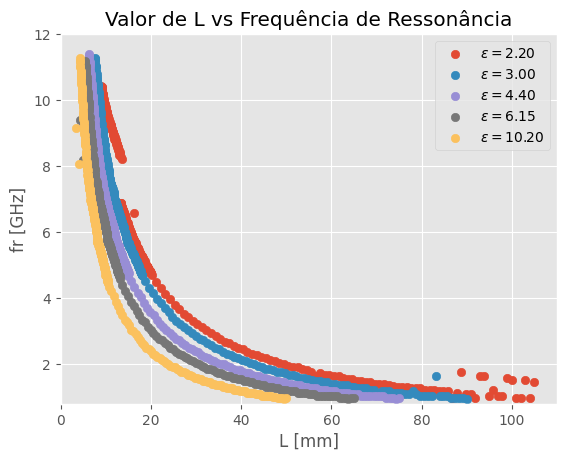

In [ ]:
# Scatter plot with the filtered data
plt.style.use("ggplot")
plt.title('Valor de L vs Frequência de Ressonância')
plt.xlabel('L [mm]')
plt.ylabel('fr [GHz]')
plt.xlim([0, 110])
plt.ylim([0.8, 12])
plt.scatter(df_final_22['L'], df_final_22 ['Freq'])
plt.scatter(df_final_30['L'], df_final_30 ['Freq'])
plt.scatter(df_final_44['L'], df_final_44 ['Freq'])
plt.scatter(df_final_615['L'], df_final_615 ['Freq'])
plt.scatter(df_final_102['L'], df_final_102 ['Freq'])
plt.legend(["$\epsilon = 2.20$",
            "$\epsilon = 3.00$",
            "$\epsilon = 4.40$",
            "$\epsilon = 6.15$",
            "$\epsilon = 10.20$"])

plt.show()

---